# Classificação de Doenças Respiratórias a Partir de Sintomas
## Utilizando Técnicas de Aprendizagem de Máquina

**Alunos:** João Matheus de Figueirêdo Tavares e Caio Moura Portela de Sousa  
**Curso:** Sistemas de Informação - UNIFACISA  
**Professor:** Bruno Rafael Araújo Vasconcelos  
**Dataset:** [Diseases and Symptoms - Kaggle](https://www.kaggle.com/datasets/dhivyeshrk/diseases-and-symptoms-dataset)  
**Ambiente:** Jupyter Notebook com Python 3, Scikit-learn, Pandas, Matplotlib e Seaborn

---

## Abstract

This work presents the development and evaluation of machine learning models for classifying three respiratory diseases (**Pneumonia**, **Acute Bronchitis**, and **Asthma**) based on binary symptom variables from a public Kaggle dataset. The original dataset was filtered to the selected diseases, non-informative symptoms were removed, and feature selection was performed with **SelectKBest** and the Chi-Square test using only the training data to avoid data leakage. Four algorithms were compared: Decision Tree, Random Forest, Logistic Regression, and Multilayer Perceptron (MLP). Model quality was assessed using accuracy, precision, recall, F1-score, confusion matrices, and stratified cross-validation. The best final test performance was achieved by **Logistic Regression**, with **90.19% accuracy** and **0.9026 weighted F1-score**.

**Keywords:** machine learning, disease classification, feature selection, respiratory symptoms, confusion matrix.

## Resumo

Este trabalho apresenta o desenvolvimento e a avaliação de modelos de aprendizagem de máquina para a classificação de três doenças respiratórias (**Pneumonia**, **Bronquite Aguda** e **Asma**) a partir de sintomas binários de um dataset público do Kaggle. A base original foi filtrada para as doenças escolhidas, sintomas sem variância foram removidos e a seleção de variáveis foi realizada com **SelectKBest** e teste Qui-Quadrado somente sobre os dados de treinamento, evitando vazamento de informação para o conjunto de teste. Foram comparados quatro algoritmos: Árvore de Decisão, Random Forest, Regressão Logística e Rede Neural MLP. A avaliação utiliza acurácia, precisão, recall, F1-Score, matriz de confusão e validação cruzada estratificada. O melhor desempenho final foi obtido pela **Regressão Logística**, com **90,19% de acurácia** e **F1-Score ponderado de 0,9026** no conjunto de teste.

**Palavras-chave:** aprendizagem de máquina, classificação de doenças respiratórias, seleção de features, matriz de confusão, validação cruzada.

## 1. Introdução

A classificação correta de doenças a partir de sintomas é um problema relevante porque diferentes enfermidades podem compartilhar manifestações clínicas semelhantes. Sintomas como tosse, falta de ar, febre e dor no peito podem aparecer em mais de uma doença respiratória, dificultando a distinção apenas pela observação isolada de variáveis.

O objetivo deste trabalho é desenvolver e avaliar modelos de aprendizagem de máquina capazes de prever qual doença um paciente possui entre três possibilidades: **Pneumonia**, **Bronquite Aguda** e **Asma**. Para isso, foi utilizado um dataset público do Kaggle contendo doenças e sintomas em formato binário. O estudo envolve filtragem da base, análise exploratória, seleção de features, treinamento de modelos, construção de matrizes de confusão e análise de métricas de classificação.

Além da implementação dos modelos, este notebook foi estruturado como artigo científico executável, seguindo a proposta do projeto: apresenta resumo, introdução, metodologia, resultados, discussão, conclusão e referências.


## 2. Metodologia e Ferramentas

A implementação foi feita em Jupyter Notebook, utilizando bibliotecas Python voltadas para ciência de dados e aprendizagem de máquina. O Pandas foi usado para manipulação dos dados, o Scikit-learn para treinamento e avaliação dos modelos, e Matplotlib/Seaborn para visualização dos resultados.

In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, balanced_accuracy_score,
    ConfusionMatrixDisplay
)
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Configuração visual
sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12})
print('Bibliotecas importadas com sucesso!')
print(f'NumPy: {np.__version__} | Pandas: {pd.__version__}')


Bibliotecas importadas com sucesso!
NumPy: 2.0.2 | Pandas: 2.3.3


## 3. Base de Dados e Pré-processamento

O dataset original do Kaggle contém **246.945 registros** com **773 doenças** e **377 sintomas** binários.  
As três doenças escolhidas são:
- **Pneumonia** — infecção pulmonar com sintomas sistêmicos
- **Bronquite Aguda (Acute Bronchitis)** — inflamação dos brônquios
- **Asma (Asthma)** — condição alérgica crônica

**Justificativa da escolha:** são doenças respiratórias com sobreposição de sintomas, tornando a tarefa de classificação desafiadora.

In [2]:
# Carregar o dataset completo do Kaggle
df_full = pd.read_csv('Final_Augmented_dataset_Diseases_and_Symptoms.csv')
print(f'Dataset original: {df_full.shape[0]:,} amostras x {df_full.shape[1]} colunas')
print(f'Doenças únicas: {df_full["diseases"].nunique()}')

# Filtrar as 3 doenças escolhidas
DOENÇAS_ESCOLHIDAS = ['pneumonia', 'acute bronchitis', 'asthma']
df = df_full[df_full['diseases'].isin(DOENÇAS_ESCOLHIDAS)].copy().reset_index(drop=True)
print(f'\nDataset filtrado (3 doenças): {df.shape[0]:,} amostras x {df.shape[1]} colunas')
print(f'\nDistribuição das classes:')
print(df['diseases'].value_counts())

# Remover colunas com variância zero (sintomas irrelevantes)
X = df.drop('diseases', axis=1)
colunas_relevantes = X.columns[X.sum() > 0].tolist()
colunas_removidas = X.columns[X.sum() == 0].tolist()
df = df[['diseases'] + colunas_relevantes]

print(f'\nSintomas com variância > 0: {len(colunas_relevantes)}')
print(f'Sintomas removidos (todos zeros): {len(colunas_removidas)}')
print(f'Dataset limpo: {df.shape}')
print(f'Valores nulos: {df.isnull().sum().sum()}')
print(f'\nSintomas relevantes:')
for i, s in enumerate(colunas_relevantes):
    print(f'  {i+1:2d}. {s}')

Dataset original: 246,945 amostras x 378 colunas
Doenças únicas: 773

Dataset filtrado (3 doenças): 3,329 amostras x 378 colunas

Distribuição das classes:
diseases
acute bronchitis    1213
pneumonia           1212
asthma               904
Name: count, dtype: int64

Sintomas com variância > 0: 17
Sintomas removidos (todos zeros): 360
Dataset limpo: (3329, 18)
Valores nulos: 0

Sintomas relevantes:
   1. shortness of breath
   2. sharp chest pain
   3. chest tightness
   4. sore throat
   5. cough
   6. nasal congestion
   7. vomiting
   8. headache
   9. wheezing
  10. weakness
  11. fever
  12. difficulty breathing
  13. chills
  14. coughing up sputum
  15. coryza
  16. allergic reaction
  17. congestion in chest


## 4. Análise Exploratória dos Dados (EDA)

Etapa fundamental para compreender a estrutura dos dados e identificar padrões que orientem a modelagem.

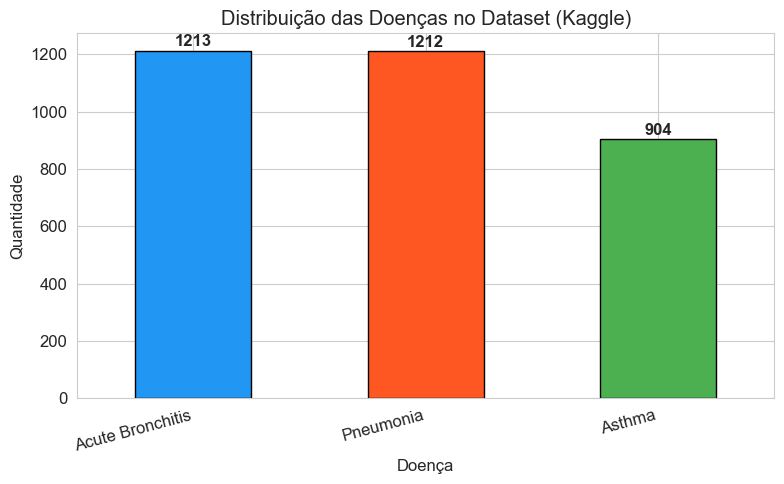

In [3]:
# 3.1 Distribuição das classes
fig, ax = plt.subplots(figsize=(8, 5))
cores = ['#2196F3', '#FF5722', '#4CAF50']
contagem = df['diseases'].value_counts()
contagem.plot(kind='bar', color=cores, ax=ax, edgecolor='black')
ax.set_title('Distribuição das Doenças no Dataset (Kaggle)')
ax.set_xlabel('Doença'); ax.set_ylabel('Quantidade')
for i, v in enumerate(contagem.values):
    ax.text(i, v+15, str(v), ha='center', fontweight='bold')
ax.set_xticklabels([d.title() for d in contagem.index], rotation=15, ha='right')
plt.tight_layout()
plt.show()

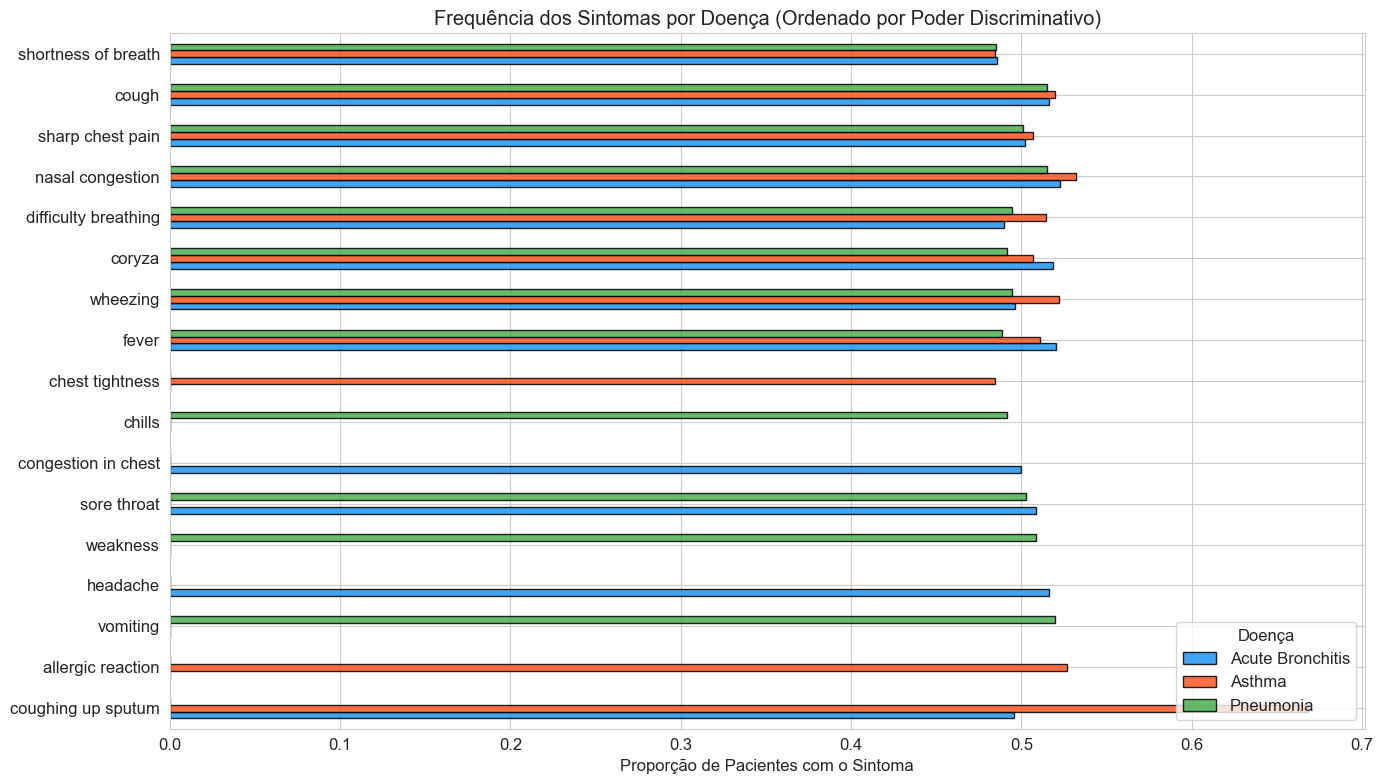

Ranking de sintomas por poder discriminativo (variância entre classes):
   1. coughing up sputum                  variância = 0.1203
   2. allergic reaction                   variância = 0.0924
   3. vomiting                            variância = 0.0901
   4. headache                            variância = 0.0888
   5. weakness                            variância = 0.0861
   6. sore throat                         variância = 0.0852
   7. congestion in chest                 variância = 0.0832
   8. chills                              variância = 0.0806
   9. chest tightness                     variância = 0.0783
  10. fever                               variância = 0.0003
  11. wheezing                            variância = 0.0002
  12. coryza                              variância = 0.0002
  13. difficulty breathing                variância = 0.0002
  14. nasal congestion                    variância = 0.0001
  15. sharp chest pain                    variância = 0.0000
  16. cough  

In [4]:
# 3.2 Frequência dos sintomas por doença
X = df.drop('diseases', axis=1)
frequencia_por_doenca = df.groupby('diseases')[X.columns.tolist()].mean()
variancia_entre_classes = frequencia_por_doenca.var(axis=0).sort_values(ascending=False)
sintomas_ordenados = variancia_entre_classes.index.tolist()

fig, ax = plt.subplots(figsize=(14, 8))
freq_plot = frequencia_por_doenca[sintomas_ordenados].T
freq_plot.columns = [c.title() for c in freq_plot.columns]
freq_plot.plot(kind='barh', ax=ax, color=cores, edgecolor='black', alpha=0.85)
ax.set_title('Frequência dos Sintomas por Doença (Ordenado por Poder Discriminativo)')
ax.set_xlabel('Proporção de Pacientes com o Sintoma')
ax.legend(title='Doença', loc='lower right')
plt.tight_layout()
plt.show()

print('Ranking de sintomas por poder discriminativo (variância entre classes):')
for i, (s, v) in enumerate(variancia_entre_classes.items()):
    print(f'  {i+1:2d}. {s:35s} variância = {v:.4f}')

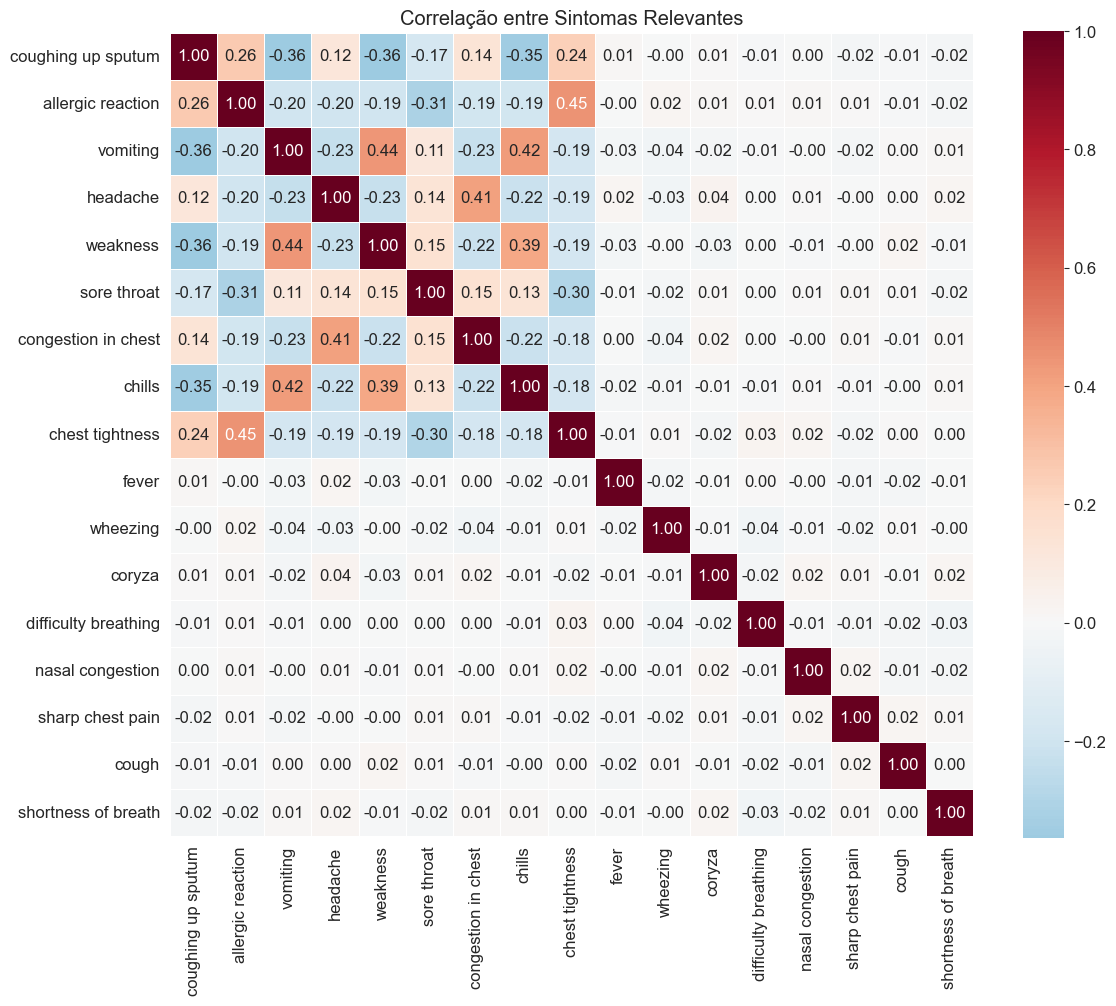

In [5]:
# 3.3 Heatmap de correlação entre sintomas
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[sintomas_ordenados].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlação entre Sintomas Relevantes')
plt.tight_layout()
plt.show()

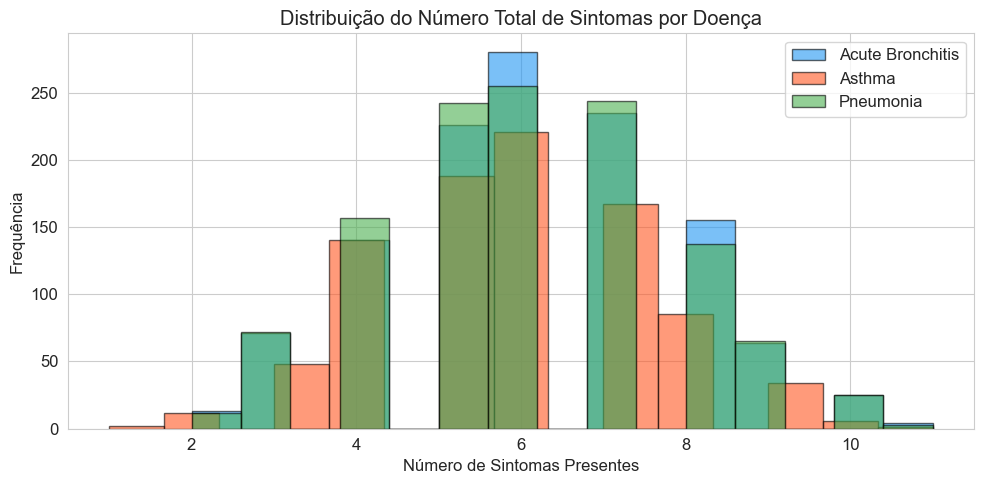

Estatísticas do total de sintomas por doença:
                   count  mean   std  min  25%  50%  75%   max
diseases                                                      
acute bronchitis  1213.0  6.07  1.71  2.0  5.0  6.0  7.0  11.0
asthma             904.0  5.78  1.60  1.0  5.0  6.0  7.0  11.0
pneumonia         1212.0  6.01  1.72  2.0  5.0  6.0  7.0  11.0


In [6]:
# 3.4 Total de sintomas por paciente por doença
df_temp = df.copy()
df_temp['total_sintomas'] = X.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
for i, doenca in enumerate(sorted(df['diseases'].unique())):
    subset = df_temp[df_temp['diseases'] == doenca]['total_sintomas']
    ax.hist(subset, bins=15, alpha=0.6, label=doenca.title(), color=cores[i], edgecolor='black')
ax.set_title('Distribuição do Número Total de Sintomas por Doença')
ax.set_xlabel('Número de Sintomas Presentes'); ax.set_ylabel('Frequência')
ax.legend()
plt.tight_layout()
plt.show()

print('Estatísticas do total de sintomas por doença:')
print(df_temp.groupby('diseases')['total_sintomas'].describe().round(2))

## 5. Seleção de Features (Feature Selection)

A seleção de features é essencial para:
- **Reduzir o overfitting** ao eliminar variáveis irrelevantes
- **Diminuir o tempo de treinamento** dos modelos
- **Melhorar a interpretabilidade** dos resultados

Técnicas utilizadas: **SelectKBest com teste Qui-Quadrado** e **Informação Mútua**.

No dataset filtrado, primeiro foram removidas as colunas sem variância, reduzindo o conjunto original de **377 sintomas** para **17 sintomas relevantes**. Em seguida, a base foi dividida em treino e teste com estratificação. A escolha do número de atributos foi feita apenas com o conjunto de treinamento, usando validação cruzada estratificada. Essa decisão metodológica evita **vazamento de dados**, isto é, impede que informações do conjunto de teste influenciem a seleção das variáveis.


Classes: {0: 'Bronquite Aguda', 1: 'Asma', 2: 'Pneumonia'}
Conjunto de treino: 2330 amostras
Conjunto de teste:  999 amostras
Features candidatas: 17


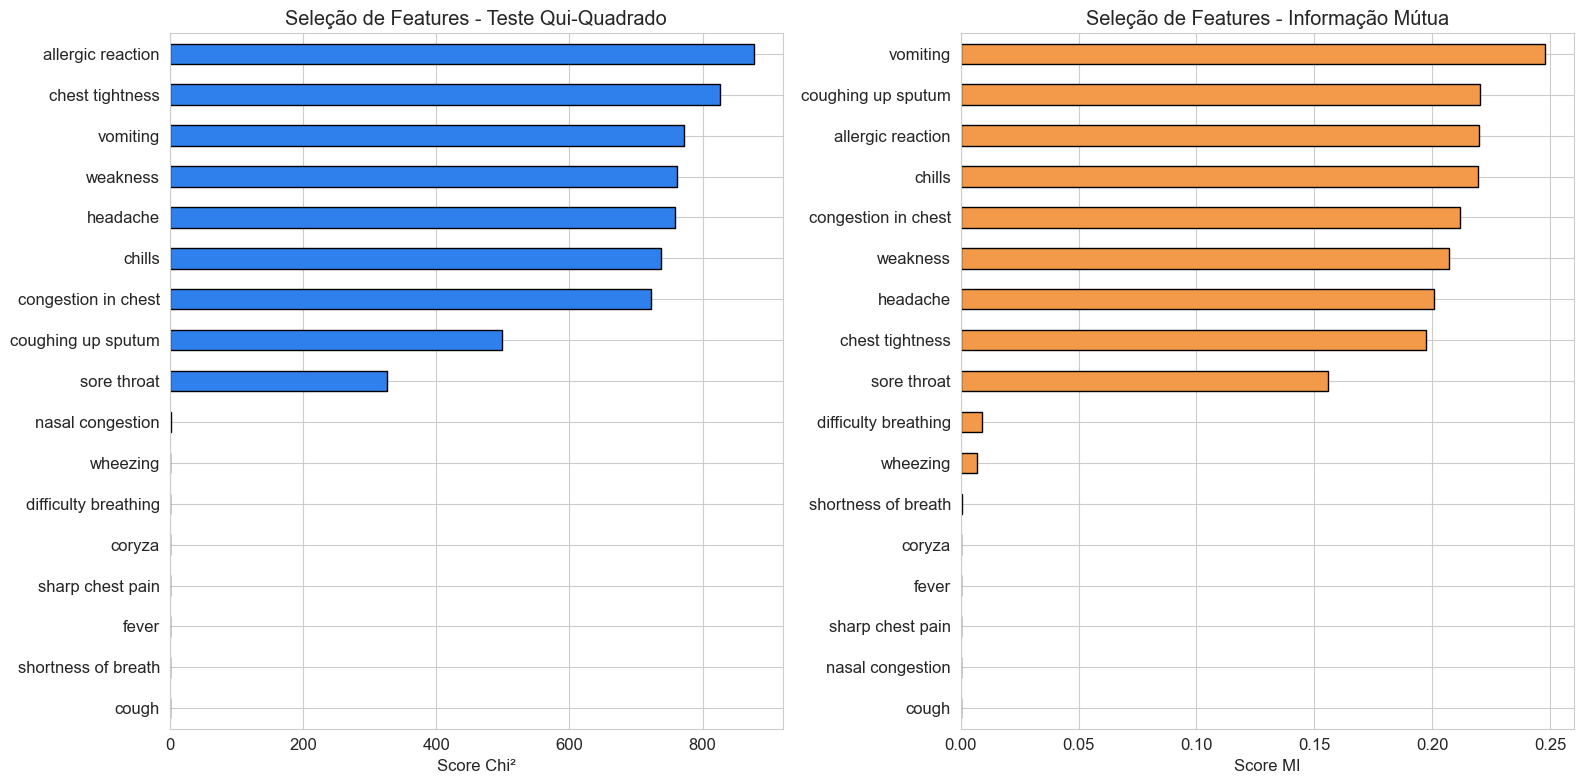

### Ranking de Features pelo Conjunto de Treinamento

,Chi²,Info. Mútua
allergic reaction,876.6493,0.2196
chest tightness,825.7125,0.1973
vomiting,772.4575,0.2477
weakness,761.9717,0.2072
headache,758.8163,0.2006
chills,737.5047,0.2194
congestion in chest,722.1837,0.2115
coughing up sputum,498.5371,0.2204
sore throat,326.4164,0.1558
nasal congestion,2.0402,0.0000


In [7]:
# Codificar variável-alvo
le = LabelEncoder()
y_codificado = le.fit_transform(df['diseases'])
classes = le.classes_
nomes_classes_pt = {
    'acute bronchitis': 'Bronquite Aguda',
    'asthma': 'Asma',
    'pneumonia': 'Pneumonia',
}
classes_titulo = [nomes_classes_pt.get(c, c.title()) for c in classes]
print(f'Classes: {dict(zip(range(len(classes)), classes_titulo))}')

X_base = X.copy()

# A divisão treino/teste é feita antes da seleção de features para evitar vazamento de dados
X_treino_base, X_teste_base, y_treino, y_teste = train_test_split(
    X_base, y_codificado, test_size=0.3, random_state=42, stratify=y_codificado
)

print(f'Conjunto de treino: {X_treino_base.shape[0]} amostras')
print(f'Conjunto de teste:  {X_teste_base.shape[0]} amostras')
print(f'Features candidatas: {X_base.shape[1]}')

# 5.1 Teste Qui-Quadrado calculado somente no conjunto de treino
seletor_chi2 = SelectKBest(chi2, k='all')
seletor_chi2.fit(X_treino_base, y_treino)
scores_chi2 = pd.Series(seletor_chi2.scores_, index=X_base.columns).sort_values(ascending=False)

# 5.2 Informação Mútua calculada somente no conjunto de treino
scores_mi = pd.Series(
    mutual_info_classif(X_treino_base, y_treino, random_state=42),
    index=X_base.columns
).sort_values(ascending=False)

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
scores_chi2.sort_values().plot(kind='barh', color='#2F80ED', edgecolor='black', ax=axes[0])
axes[0].set_title('Seleção de Features - Teste Qui-Quadrado')
axes[0].set_xlabel('Score Chi²')
scores_mi.sort_values().plot(kind='barh', color='#F2994A', edgecolor='black', ax=axes[1])
axes[1].set_title('Seleção de Features - Informação Mútua')
axes[1].set_xlabel('Score MI')
plt.tight_layout()
plt.show()

# Tabela comparativa
comparacao_features = pd.DataFrame({'Chi²': scores_chi2, 'Info. Mútua': scores_mi}).sort_values('Chi²', ascending=False)
display(Markdown('### Ranking de Features pelo Conjunto de Treinamento'))
display(comparacao_features.round(4))


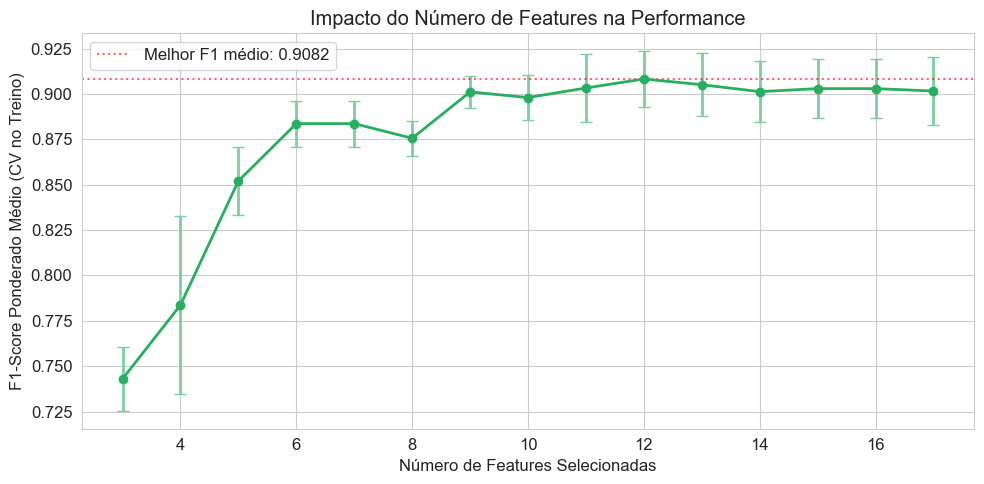

Total de features disponíveis após limpeza: 17
Melhor quantidade de features pela validação cruzada no treino: 12
Features selecionadas para modelagem: 12

Features selecionadas:
   1. chest tightness
   2. sore throat
   3. nasal congestion
   4. vomiting
   5. headache
   6. wheezing
   7. weakness
   8. difficulty breathing
   9. chills
  10. coughing up sputum
  11. allergic reaction
  12. congestion in chest


### Impacto da Seleção de Features

,Cenário,Qtd. features,Acurácia,F1-Score
0,Todas as features relevantes,17,0.8969,0.8966
1,Features selecionadas,12,0.8969,0.8966


### Features Selecionadas e Seus Scores

,Chi²,Info. Mútua
allergic reaction,876.6493,0.2196
chest tightness,825.7125,0.1973
vomiting,772.4575,0.2477
weakness,761.9717,0.2072
headache,758.8163,0.2006
chills,737.5047,0.2194
congestion in chest,722.1837,0.2115
coughing up sputum,498.5371,0.2204
sore throat,326.4164,0.1558
nasal congestion,2.0402,0.0000


In [8]:
# 5.3 Impacto do número de features na performance
n_total_features = X_base.shape[1]
k_valores = list(range(3, n_total_features + 1))
cv_feature_selection = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_k = []
for k in k_valores:
    pipeline_k = Pipeline([
        ('seletor', SelectKBest(chi2, k=k)),
        ('modelo', DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42))
    ])
    scores = cross_val_score(
        pipeline_k, X_treino_base, y_treino,
        cv=cv_feature_selection, scoring='f1_weighted'
    )
    resultados_k.append({
        'k': k,
        'F1 ponderado médio': scores.mean(),
        'Desvio padrão': scores.std(),
    })

df_k_features = pd.DataFrame(resultados_k)

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    df_k_features['k'], df_k_features['F1 ponderado médio'],
    yerr=df_k_features['Desvio padrão'], fmt='o-', color='#27AE60',
    ecolor='#7DCEA0', capsize=4, linewidth=2
)
ax.set_xlabel('Número de Features Selecionadas')
ax.set_ylabel('F1-Score Ponderado Médio (CV no Treino)')
ax.set_title('Impacto do Número de Features na Performance')
ax.axhline(
    y=df_k_features['F1 ponderado médio'].max(), color='red', linestyle=':', alpha=0.6,
    label=f"Melhor F1 médio: {df_k_features['F1 ponderado médio'].max():.4f}"
)
ax.legend()
plt.tight_layout()
plt.show()

# Selecionar automaticamente o melhor subconjunto de features com base na validação cruzada do treino
idx_melhor = df_k_features['F1 ponderado médio'].idxmax()
k_melhor = int(df_k_features.loc[idx_melhor, 'k'])
seletor_final = SelectKBest(chi2, k=k_melhor)
seletor_final.fit(X_treino_base, y_treino)
features_selecionadas = X_base.columns[seletor_final.get_support()].tolist()

X_treino = X_treino_base[features_selecionadas].copy()
X_teste = X_teste_base[features_selecionadas].copy()
X_final = X_base[features_selecionadas].copy()

print(f'Total de features disponíveis após limpeza: {n_total_features}')
print(f'Melhor quantidade de features pela validação cruzada no treino: {k_melhor}')
print(f'Features selecionadas para modelagem: {len(features_selecionadas)}')
print()
print('Features selecionadas:')
for i, feature in enumerate(features_selecionadas, start=1):
    print(f'  {i:2d}. {feature}')

# Comparar modelo com todas as features versus features selecionadas no conjunto de teste final
modelo_base_todas = DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42)
modelo_base_sel = DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42)

modelo_base_todas.fit(X_treino_base, y_treino)
pred_todas = modelo_base_todas.predict(X_teste_base)

modelo_base_sel.fit(X_treino, y_treino)
pred_sel = modelo_base_sel.predict(X_teste)

df_impacto_features = pd.DataFrame([
    {
        'Cenário': 'Todas as features relevantes',
        'Qtd. features': X_treino_base.shape[1],
        'Acurácia': accuracy_score(y_teste, pred_todas),
        'F1-Score': f1_score(y_teste, pred_todas, average='weighted'),
    },
    {
        'Cenário': 'Features selecionadas',
        'Qtd. features': X_treino.shape[1],
        'Acurácia': accuracy_score(y_teste, pred_sel),
        'F1-Score': f1_score(y_teste, pred_sel, average='weighted'),
    }
])

display(Markdown('### Impacto da Seleção de Features'))
display(df_impacto_features.style.format({'Acurácia': '{:.4f}', 'F1-Score': '{:.4f}'}))

features_rankeadas = comparacao_features.loc[features_selecionadas].sort_values('Chi²', ascending=False)
display(Markdown('### Features Selecionadas e Seus Scores'))
display(features_rankeadas.round(4))


## 6. Modelagem e Avaliação

Quatro modelos foram implementados e comparados para evitar uma escolha sem justificativa experimental:
- **Árvore de Decisão** — modelo interpretável, bom para dados binários e útil para entender regras de decisão
- **Random Forest** — ensemble de árvores, reduz a variância de uma árvore isolada e permite analisar importância das features
- **Regressão Logística** — modelo linear robusto, adequado como baseline para classificação multiclasse
- **Rede Neural (MLP)** — modelo não-linear, capaz de capturar combinações mais complexas entre sintomas

**Divisão dos dados:** 70% treino e 30% teste com estratificação. A divisão foi feita antes da seleção de features, garantindo que o conjunto de teste permaneça independente até a avaliação final.

**Métricas utilizadas:** matriz de confusão, acurácia, precisão ponderada, recall ponderado, F1-Score ponderado, F1 macro, acurácia balanceada e validação cruzada estratificada com 5 folds. Essas métricas são adequadas ao problema porque se trata de uma classificação multiclasse e há diferença moderada entre as quantidades de amostras por doença.

**Critério de escolha do melhor modelo:** o F1-Score ponderado foi usado como principal critério porque combina precisão e recall, sendo mais informativo que olhar apenas a acurácia.


In [9]:
# Preparar dados finais
print(f'Conjunto de treino: {X_treino.shape[0]} amostras')
print(f'Conjunto de teste:  {X_teste.shape[0]} amostras')
print(f'Features utilizadas: {len(features_selecionadas)}')

# Definir modelos
modelos = {
    'Árvore de Decisão': DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=5, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=3,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Regressão Logística': LogisticRegression(
        max_iter=1000, C=1.0, class_weight='balanced', random_state=42
    ),
    'Rede Neural (MLP)': MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=500,
        random_state=42, early_stopping=True
    ),
}

# Validação cruzada estratificada no conjunto de treino
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'f1_weighted': 'f1_weighted',
}

# Treinar e avaliar cada modelo
resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    y_pred = modelo.predict(X_teste)
    cv_scores = cross_validate(modelo, X_treino, y_treino, cv=cv, scoring=scoring)
    relatorio = classification_report(
        y_teste, y_pred, target_names=classes_titulo, output_dict=True
    )
    matriz = confusion_matrix(y_teste, y_pred)

    resultados[nome] = {
        'modelo': modelo,
        'y_pred': y_pred,
        'acuracia': accuracy_score(y_teste, y_pred),
        'acuracia_balanceada': balanced_accuracy_score(y_teste, y_pred),
        'precisao': precision_score(y_teste, y_pred, average='weighted'),
        'recall': recall_score(y_teste, y_pred, average='weighted'),
        'f1': f1_score(y_teste, y_pred, average='weighted'),
        'f1_macro': f1_score(y_teste, y_pred, average='macro'),
        'cv_media': cv_scores['test_accuracy'].mean(),
        'cv_std': cv_scores['test_accuracy'].std(),
        'cv_f1_media': cv_scores['test_f1_weighted'].mean(),
        'cv_f1_std': cv_scores['test_f1_weighted'].std(),
        'matriz_confusao': matriz,
        'relatorio': relatorio,
    }

    print()
    print(f'{"=" * 50}')
    print(f'{nome}')
    print(f'{"=" * 50}')
    print(f'  Acurácia:             {resultados[nome]["acuracia"]:.4f}')
    print(f'  Acurácia balanceada:  {resultados[nome]["acuracia_balanceada"]:.4f}')
    print(f'  Precisão ponderada:   {resultados[nome]["precisao"]:.4f}')
    print(f'  Recall ponderado:     {resultados[nome]["recall"]:.4f}')
    print(f'  F1-Score ponderado:   {resultados[nome]["f1"]:.4f}')
    print(f'  F1 macro:             {resultados[nome]["f1_macro"]:.4f}')
    print(f'  CV acurácia 5-fold:   {resultados[nome]["cv_media"]:.4f} ± {resultados[nome]["cv_std"]:.4f}')
    print(f'  CV F1 5-fold:         {resultados[nome]["cv_f1_media"]:.4f} ± {resultados[nome]["cv_f1_std"]:.4f}')
    print()
    print(classification_report(y_teste, y_pred, target_names=classes_titulo))


Conjunto de treino: 2330 amostras
Conjunto de teste:  999 amostras
Features utilizadas: 12

Árvore de Decisão
  Acurácia:             0.8999
  Acurácia balanceada:  0.9084
  Precisão ponderada:   0.9142
  Recall ponderado:     0.8999
  F1-Score ponderado:   0.9010
  F1 macro:             0.8988
  CV acurácia 5-fold:   0.9094 ± 0.0100
  CV F1 5-fold:         0.9101 ± 0.0105

                 precision    recall  f1-score   support

Bronquite Aguda       0.96      0.83      0.89       364
           Asma       0.78      1.00      0.88       271
      Pneumonia       0.97      0.90      0.93       364

       accuracy                           0.90       999
      macro avg       0.90      0.91      0.90       999
   weighted avg       0.91      0.90      0.90       999


Random Forest
  Acurácia:             0.8979
  Acurácia balanceada:  0.9060
  Precisão ponderada:   0.9081
  Recall ponderado:     0.8979
  F1-Score ponderado:   0.8983
  F1 macro:             0.8971
  CV acurácia 5-fold

## 7. Matrizes de Confusão

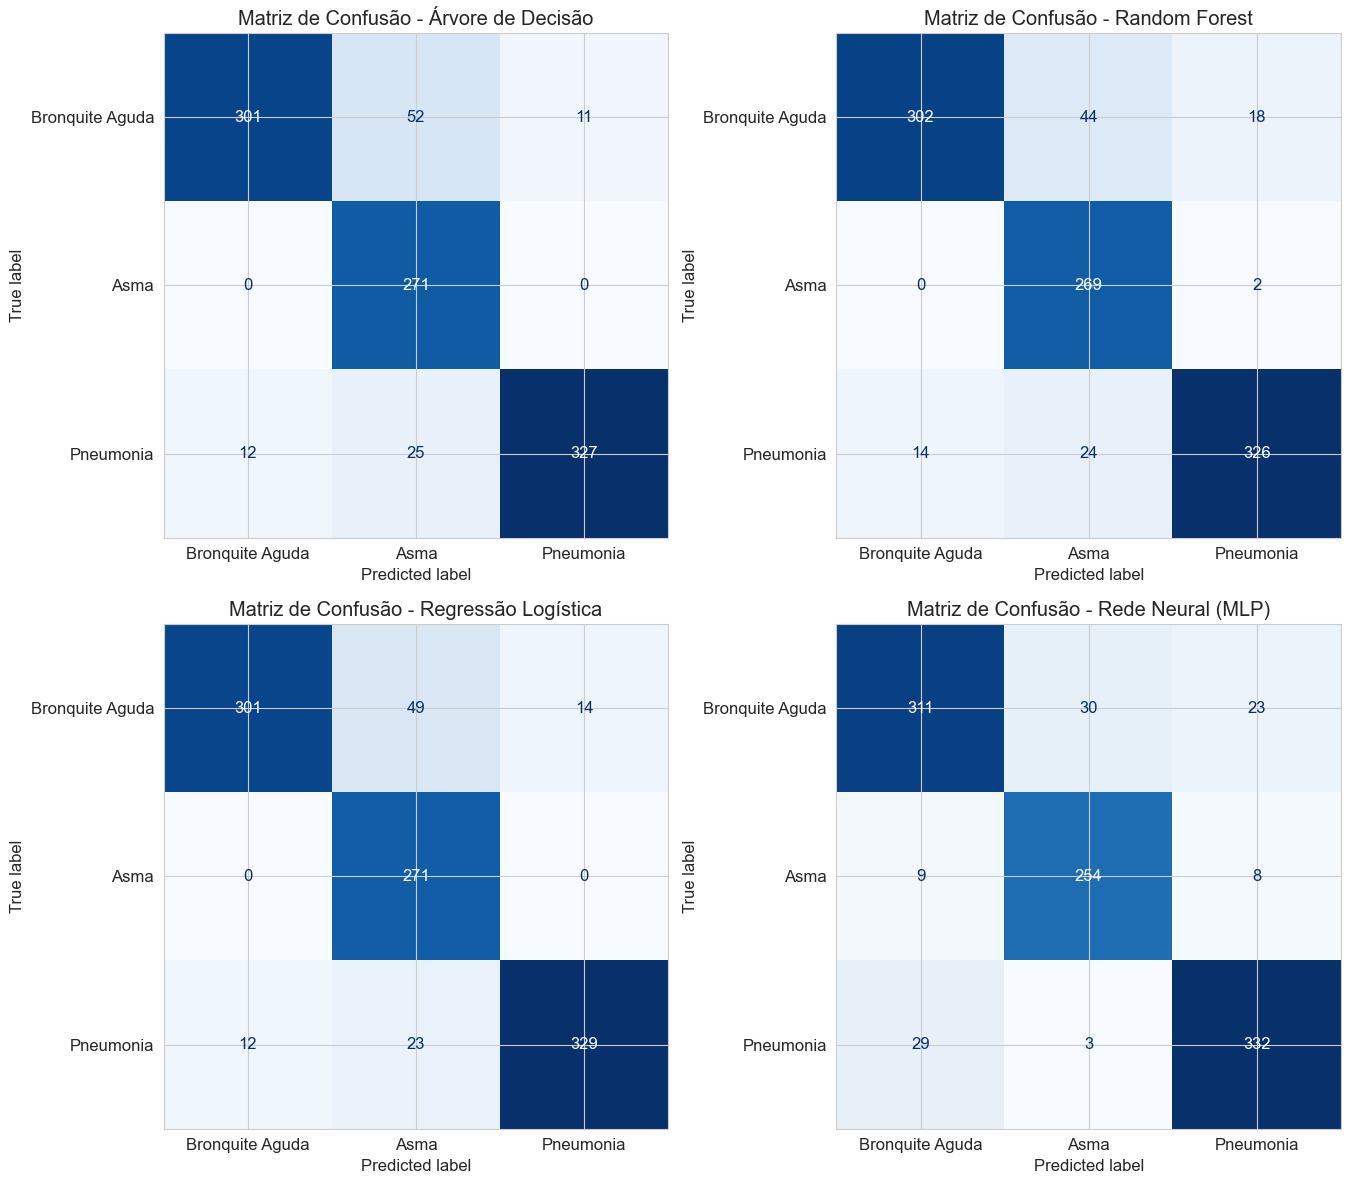

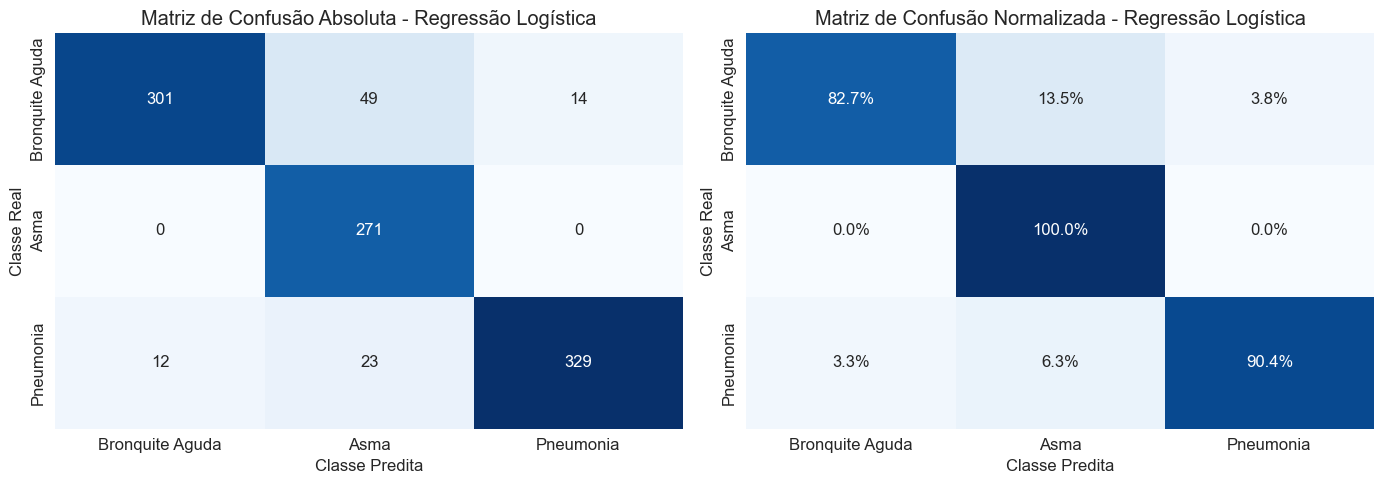

### Análise da Matriz de Confusão - Regressão Logística

,Classe real,Total,Acertos,Erros,Recall da classe,Principal confusão,Quantidade
0,Bronquite Aguda,364,301,63,82.69%,Asma,49
1,Asma,271,271,0,100.00%,Sem erro,0
2,Pneumonia,364,329,35,90.38%,Asma,23


### Principais Confusões Entre Classes

,Classe real,Classe predita,Erros,Taxa dentro da classe real
0,Bronquite Aguda,Asma,49,13.46%
1,Pneumonia,Asma,23,6.32%
2,Bronquite Aguda,Pneumonia,14,3.85%
3,Pneumonia,Bronquite Aguda,12,3.30%


A maior confusão ocorreu quando casos reais de **Bronquite Aguda** foram classificados como **Asma** (49 casos). Uma explicação provável é que bronquite aguda e asma compartilham sintomas respiratórios como tosse, falta de ar, chiado e aperto no peito, o que reduz a separação entre as classes quando só há variáveis binárias.

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (nome, res) in zip(axes.flatten(), resultados.items()):
    ConfusionMatrixDisplay(
        res['matriz_confusao'], display_labels=classes_titulo
    ).plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(f'Matriz de Confusão - {nome}')
plt.tight_layout()
plt.show()

# Heatmaps e análise detalhada dos erros do melhor modelo pelo F1-Score
melhor_nome_confusao = max(resultados, key=lambda nome: resultados[nome]['f1'])
matriz_melhor = resultados[melhor_nome_confusao]['matriz_confusao']
matriz_normalizada = matriz_melhor / matriz_melhor.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    matriz_melhor, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=classes_titulo, yticklabels=classes_titulo, ax=axes[0]
)
axes[0].set_title(f'Matriz de Confusão Absoluta - {melhor_nome_confusao}')
axes[0].set_xlabel('Classe Predita')
axes[0].set_ylabel('Classe Real')

sns.heatmap(
    matriz_normalizada, annot=True, fmt='.1%', cmap='Blues', cbar=False,
    xticklabels=classes_titulo, yticklabels=classes_titulo, ax=axes[1]
)
axes[1].set_title(f'Matriz de Confusão Normalizada - {melhor_nome_confusao}')
axes[1].set_xlabel('Classe Predita')
axes[1].set_ylabel('Classe Real')
plt.tight_layout()
plt.show()

analise_erros = []
confusoes = []
for i, classe_real in enumerate(classes_titulo):
    total_classe = matriz_melhor[i].sum()
    acertos = matriz_melhor[i, i]
    erros = total_classe - acertos
    destinos_erro = []
    for j, classe_predita in enumerate(classes_titulo):
        if i == j:
            continue
        qtd = matriz_melhor[i, j]
        if qtd > 0:
            destinos_erro.append((classe_predita, qtd))
            confusoes.append({
                'Classe real': classe_real,
                'Classe predita': classe_predita,
                'Erros': qtd,
                'Taxa dentro da classe real': qtd / total_classe,
            })
    principal_confusao = max(destinos_erro, key=lambda item: item[1]) if destinos_erro else ('Sem erro', 0)
    analise_erros.append({
        'Classe real': classe_real,
        'Total': total_classe,
        'Acertos': acertos,
        'Erros': erros,
        'Recall da classe': acertos / total_classe,
        'Principal confusão': principal_confusao[0],
        'Quantidade': principal_confusao[1],
    })

df_analise_erros = pd.DataFrame(analise_erros)
df_confusoes = pd.DataFrame(confusoes).sort_values('Erros', ascending=False).reset_index(drop=True)

display(Markdown(f'### Análise da Matriz de Confusão - {melhor_nome_confusao}'))
display(df_analise_erros.style.format({'Recall da classe': '{:.2%}'}))

display(Markdown('### Principais Confusões Entre Classes'))
if df_confusoes.empty:
    display(Markdown('O melhor modelo não apresentou erros no conjunto de teste.'))
else:
    display(df_confusoes.style.format({'Taxa dentro da classe real': '{:.2%}'}))


def explicar_motivo_confusao(classe_real, classe_predita):
    par = {classe_real, classe_predita}
    if {'Bronquite Aguda', 'Asma'} == par:
        return 'bronquite aguda e asma compartilham sintomas respiratórios como tosse, falta de ar, chiado e aperto no peito, o que reduz a separação entre as classes quando só há variáveis binárias.'
    if {'Bronquite Aguda', 'Pneumonia'} == par:
        return 'bronquite aguda e pneumonia podem apresentar tosse, expectoração, febre, dor/desconforto torácico e sintomas sistêmicos semelhantes.'
    if {'Asma', 'Pneumonia'} == par:
        return 'asma e pneumonia podem envolver falta de ar e desconforto respiratório, embora tenham causas clínicas diferentes.'
    return 'as classes compartilham sintomas respiratórios e o dataset não inclui exames clínicos, intensidade dos sintomas ou histórico do paciente.'

if not df_confusoes.empty:
    maior_confusao = df_confusoes.iloc[0]
    motivo = explicar_motivo_confusao(maior_confusao['Classe real'], maior_confusao['Classe predita'])
    display(Markdown(
        f"A maior confusão ocorreu quando casos reais de **{maior_confusao['Classe real']}** "
        f"foram classificados como **{maior_confusao['Classe predita']}** "
        f"({int(maior_confusao['Erros'])} casos). Uma explicação provável é que {motivo}"
    ))


## 8. Comparação de Métricas entre Modelos

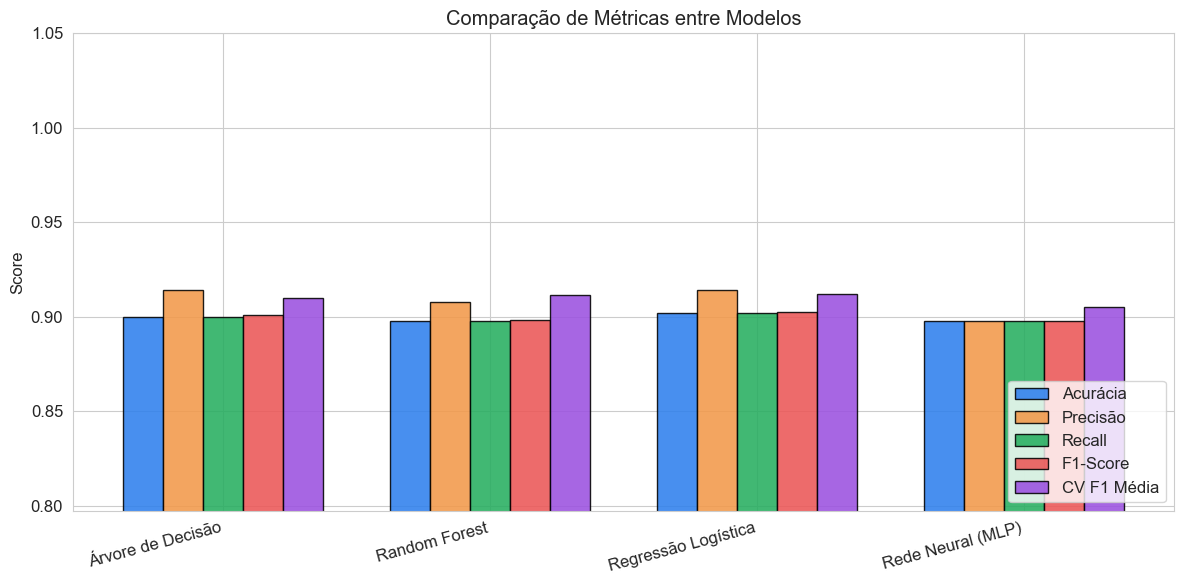

### Tabela de Resultados Consolidados

,Acurácia,Acurácia Balanceada,Precisão,Recall,F1-Score,F1 Macro,CV Média,CV F1 Média
Árvore de Decisão,0.8999,0.9084,0.9142,0.8999,0.9010,0.8988,0.9094,0.9101
Random Forest,0.8979,0.9060,0.9081,0.8979,0.8983,0.8971,0.9112,0.9115
Regressão Logística,0.9019,0.9103,0.9142,0.9019,0.9026,0.9009,0.9116,0.9123
Rede Neural (MLP),0.8979,0.9013,0.8980,0.8979,0.8976,0.8987,0.9052,0.9053



Melhor modelo pelo F1-Score ponderado: Regressão Logística
Melhor modelo pela validação cruzada F1: Regressão Logística


In [11]:
# Tabela consolidada de métricas
tabela_metricas = pd.DataFrame({
    nome: {
        'Acurácia': r['acuracia'],
        'Acurácia Balanceada': r['acuracia_balanceada'],
        'Precisão': r['precisao'],
        'Recall': r['recall'],
        'F1-Score': r['f1'],
        'F1 Macro': r['f1_macro'],
        'CV Média': r['cv_media'],
        'CV F1 Média': r['cv_f1_media'],
    }
    for nome, r in resultados.items()
}).T

tabela_metricas.to_csv('metricas_resultados.csv')

# Gráfico comparativo com as métricas principais
metricas_plot = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'CV F1 Média']
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(tabela_metricas))
largura = 0.15
cores_metricas = ['#2F80ED', '#F2994A', '#27AE60', '#EB5757', '#9B51E0']
for i, col in enumerate(metricas_plot):
    ax.bar(x + i * largura, tabela_metricas[col], largura,
           label=col, color=cores_metricas[i], edgecolor='black', alpha=0.88)
ax.set_xticks(x + largura * 2)
ax.set_xticklabels(tabela_metricas.index, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Comparação de Métricas entre Modelos')
ax.legend(loc='lower right')
ax.set_ylim(max(0, tabela_metricas[metricas_plot].min().min() - 0.1), 1.05)
plt.tight_layout()
plt.show()

display(Markdown('### Tabela de Resultados Consolidados'))
display(tabela_metricas.style.format('{:.4f}'))
print()
print(f'Melhor modelo pelo F1-Score ponderado: {tabela_metricas["F1-Score"].idxmax()}')
print(f'Melhor modelo pela validação cruzada F1: {tabela_metricas["CV F1 Média"].idxmax()}')


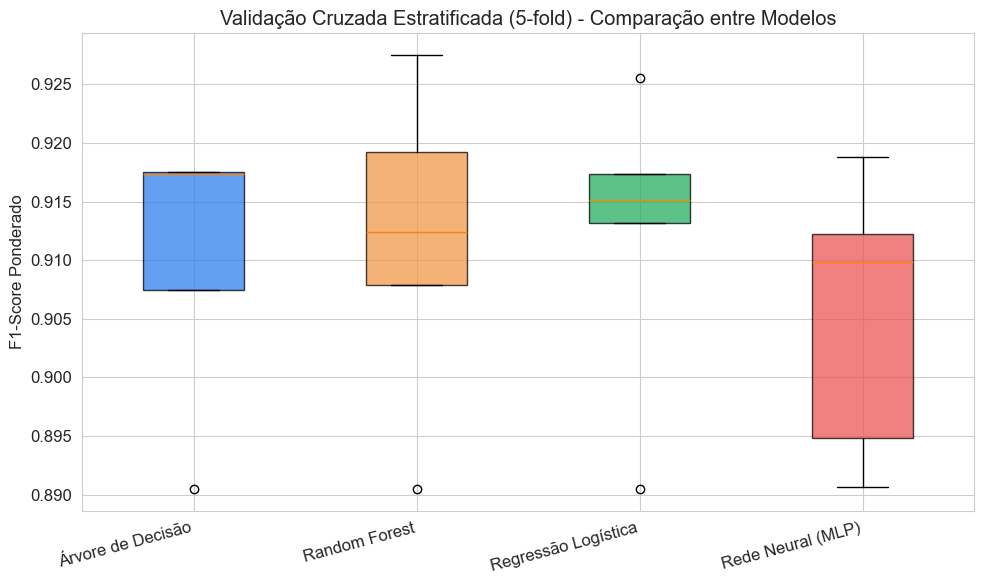

In [12]:
# Validação Cruzada - Boxplot usando F1-Score ponderado no conjunto de treino
fig, ax = plt.subplots(figsize=(10, 6))
dados_cv = [
    cross_val_score(modelo, X_treino, y_treino, cv=cv, scoring='f1_weighted')
    for modelo in modelos.values()
]
bp = ax.boxplot(dados_cv, labels=list(modelos.keys()), patch_artist=True)
cores_box = ['#2F80ED', '#F2994A', '#27AE60', '#EB5757']
for patch, cor in zip(bp['boxes'], cores_box):
    patch.set_facecolor(cor)
    patch.set_alpha(0.75)
ax.set_ylabel('F1-Score Ponderado')
ax.set_title('Validação Cruzada Estratificada (5-fold) - Comparação entre Modelos')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


## 9. Interpretabilidade dos Modelos

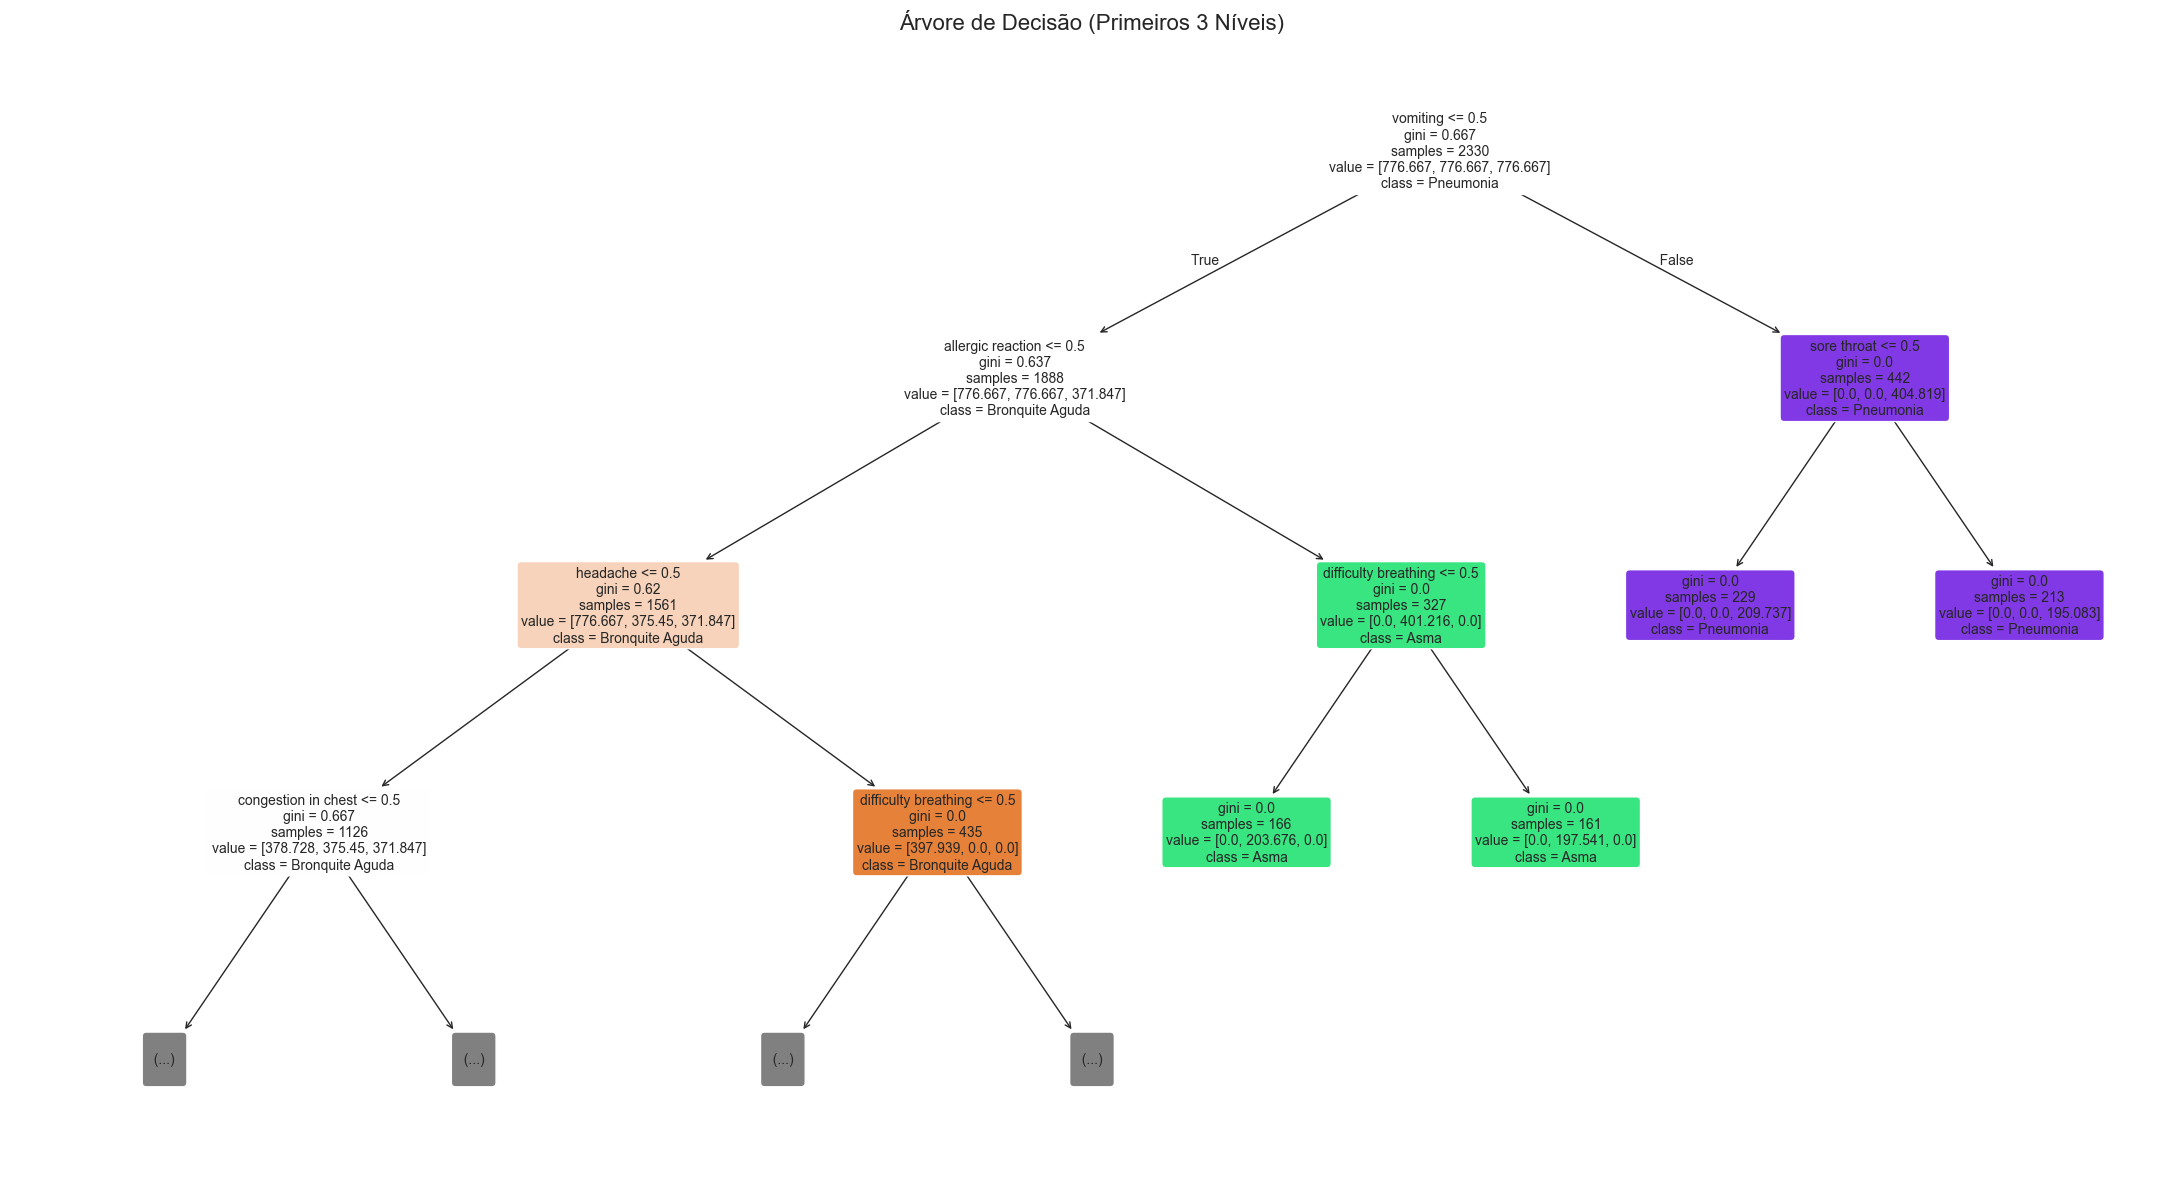

In [13]:
# 8.1 Visualização da Árvore de Decisão (primeiros 3 níveis)
fig, ax = plt.subplots(figsize=(22, 12))
plot_tree(
    resultados['Árvore de Decisão']['modelo'],
    feature_names=features_selecionadas,
    class_names=classes_titulo,
    filled=True, rounded=True, ax=ax,
    max_depth=3, fontsize=10
)
ax.set_title('Árvore de Decisão (Primeiros 3 Níveis)', fontsize=16)
plt.tight_layout()
plt.show()

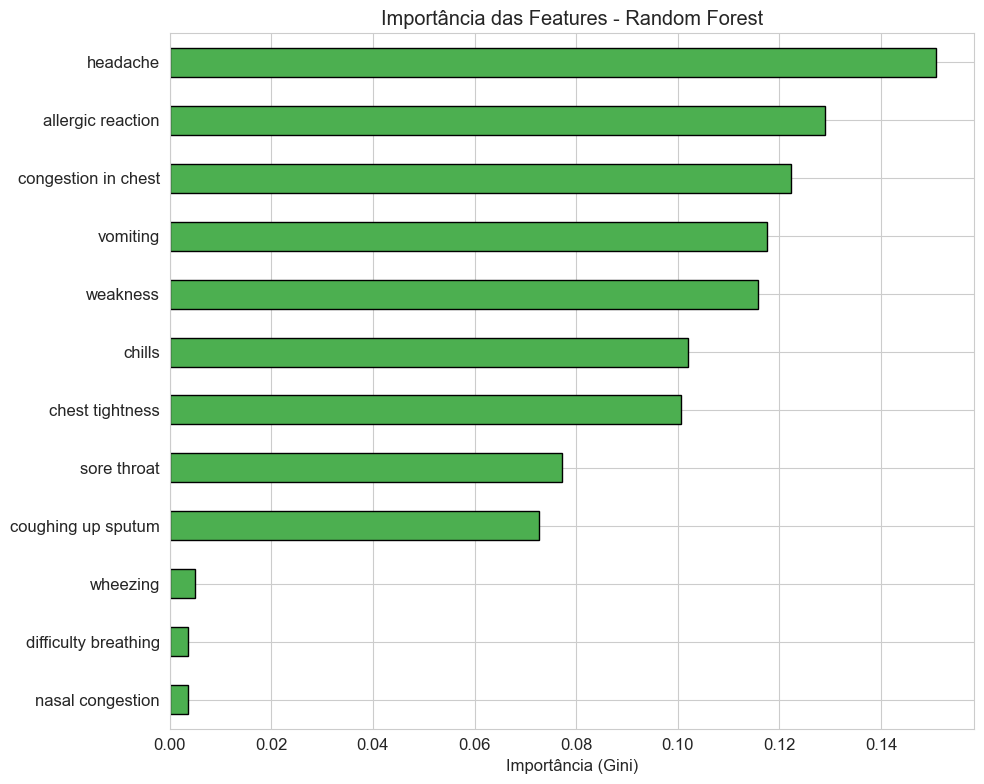

Ranking de importância das features (Random Forest):
   1. headache                            0.1507
   2. allergic reaction                   0.1289
   3. congestion in chest                 0.1224
   4. vomiting                            0.1175
   5. weakness                            0.1158
   6. chills                              0.1020
   7. chest tightness                     0.1006
   8. sore throat                         0.0772
   9. coughing up sputum                  0.0727
  10. wheezing                            0.0051
  11. difficulty breathing                0.0036
  12. nasal congestion                    0.0035


In [14]:
# 8.2 Importância das Features - Random Forest
rf = resultados['Random Forest']['modelo']
importancias = pd.Series(
    rf.feature_importances_, index=features_selecionadas
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importancias.plot(kind='barh', color='#4CAF50', edgecolor='black', ax=ax)
ax.set_title('Importância das Features - Random Forest')
ax.set_xlabel('Importância (Gini)')
plt.tight_layout()
plt.show()

print('Ranking de importância das features (Random Forest):')
for i, (feat, imp) in enumerate(importancias.sort_values(ascending=False).items()):
    print(f'  {i+1:2d}. {feat:35s} {imp:.4f}')

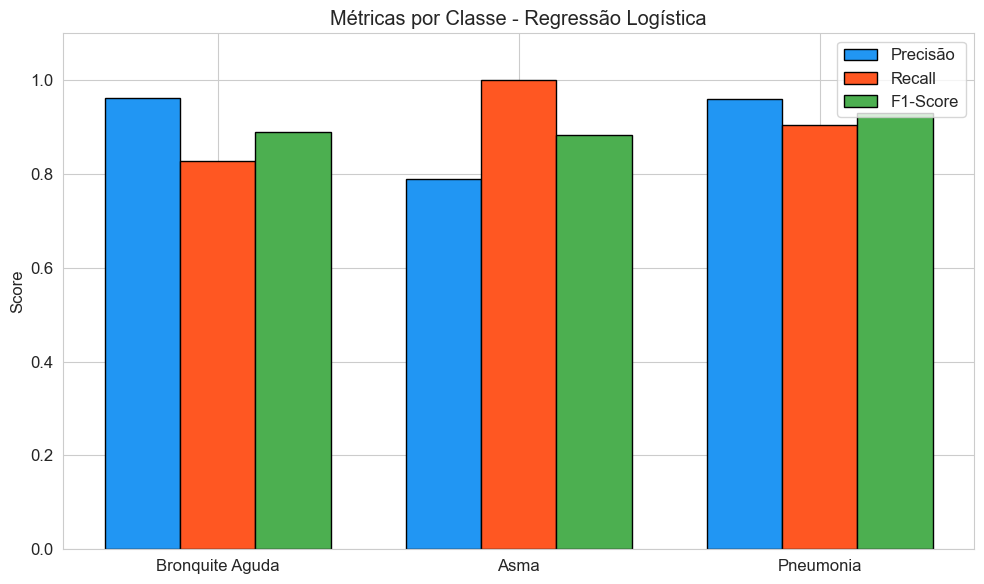


Métricas detalhadas por classe (Regressão Logística):
  Bronquite Aguda      Precisão=0.962  Recall=0.827  F1=0.889
  Asma                 Precisão=0.790  Recall=1.000  F1=0.883
  Pneumonia            Precisão=0.959  Recall=0.904  F1=0.931


In [15]:
# 8.3 Métricas por classe do melhor modelo
melhor_nome = tabela_metricas['F1-Score'].idxmax()
y_pred_melhor = resultados[melhor_nome]['y_pred']

prec_classe = precision_score(y_teste, y_pred_melhor, average=None)
rec_classe = recall_score(y_teste, y_pred_melhor, average=None)
f1_classe = f1_score(y_teste, y_pred_melhor, average=None)

fig, ax = plt.subplots(figsize=(10, 6))
x_c = np.arange(len(classes_titulo)); w = 0.25
ax.bar(x_c - w, prec_classe, w, label='Precisão', color='#2196F3', edgecolor='black')
ax.bar(x_c, rec_classe, w, label='Recall', color='#FF5722', edgecolor='black')
ax.bar(x_c + w, f1_classe, w, label='F1-Score', color='#4CAF50', edgecolor='black')
ax.set_xticks(x_c); ax.set_xticklabels(classes_titulo)
ax.set_ylabel('Score'); ax.set_title(f'Métricas por Classe - {melhor_nome}')
ax.legend(); ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

print(f'\nMétricas detalhadas por classe ({melhor_nome}):')
for i, c in enumerate(classes_titulo):
    print(f'  {c:20s} Precisão={prec_classe[i]:.3f}  Recall={rec_classe[i]:.3f}  F1={f1_classe[i]:.3f}')

## 10. Discussão dos Resultados e Diagnóstico de Overfitting

Nesta seção, os resultados são interpretados de forma acadêmica, conectando as métricas ao problema de classificação de doenças. A **acurácia** mostra a proporção geral de acertos; a **precisão** indica, entre os pacientes classificados em uma doença, quantos realmente pertencem a ela; o **recall** mostra, entre os pacientes de uma doença real, quantos foram recuperados corretamente; e o **F1-Score** combina precisão e recall em uma única medida.

Para este problema, o F1-Score é especialmente relevante porque uma boa classificação médica deve equilibrar dois tipos de erro: prever uma doença incorretamente e deixar de identificar corretamente uma doença existente. Também foi analisada a diferença entre desempenho em treino e teste para verificar sinais de overfitting.

In [16]:
# Discussão comparativa dos modelos e diagnóstico de overfitting
analise_modelos = []
for nome, res in resultados.items():
    modelo = res['modelo']
    y_pred_treino = modelo.predict(X_treino)
    acc_treino = accuracy_score(y_treino, y_pred_treino)
    f1_treino = f1_score(y_treino, y_pred_treino, average='weighted')
    acc_teste = res['acuracia']
    f1_teste = res['f1']
    gap_treino_teste = f1_treino - f1_teste
    analise_modelos.append({
        'Modelo': nome,
        'Acurácia treino': acc_treino,
        'Acurácia teste': acc_teste,
        'F1 treino': f1_treino,
        'F1 teste': f1_teste,
        'Gap F1 treino-teste': gap_treino_teste,
        'Precisão teste': res['precisao'],
        'Recall teste': res['recall'],
        'CV F1 média': res['cv_f1_media'],
        'CV F1 desvio': res['cv_f1_std'],
    })

df_overfitting = pd.DataFrame(analise_modelos).sort_values('F1 teste', ascending=False).reset_index(drop=True)
display(df_overfitting.style.format({
    'Acurácia treino': '{:.4f}',
    'Acurácia teste': '{:.4f}',
    'F1 treino': '{:.4f}',
    'F1 teste': '{:.4f}',
    'Gap F1 treino-teste': '{:.4f}',
    'Precisão teste': '{:.4f}',
    'Recall teste': '{:.4f}',
    'CV F1 média': '{:.4f}',
    'CV F1 desvio': '{:.4f}',
}))

melhor_linha = df_overfitting.iloc[0]
maior_gap = df_overfitting.sort_values('Gap F1 treino-teste', ascending=False).iloc[0]
sinal_overfitting = (
    'baixo' if melhor_linha['Gap F1 treino-teste'] < 0.03 else
    'moderado' if melhor_linha['Gap F1 treino-teste'] < 0.08 else
    'alto'
)

if melhor_linha['F1 teste'] >= 0.90 and melhor_linha['Gap F1 treino-teste'] < 0.05:
    confiabilidade = 'boa para o contexto experimental do dataset'
elif melhor_linha['F1 teste'] >= 0.80:
    confiabilidade = 'moderada, exigindo validação adicional antes de qualquer uso prático'
else:
    confiabilidade = 'limitada, indicando necessidade de melhorar dados e modelagem'

texto_metricas = f'''
### Interpretação Acadêmica das Métricas

- **Acurácia**: mede a proporção total de classificações corretas. O melhor modelo foi **{melhor_linha['Modelo']}**, com acurácia de teste de **{melhor_linha['Acurácia teste']:.4f}**.
- **Precisão**: indica a confiabilidade das previsões positivas de cada classe. No contexto do projeto, uma precisão alta significa que, quando o modelo aponta uma doença, ele tende a estar correto.
- **Recall**: mede a capacidade de encontrar corretamente os casos reais de cada doença. Em saúde, recall é relevante porque falsos negativos podem significar casos não identificados.
- **F1-Score**: combina precisão e recall. Por equilibrar os dois aspectos, foi usado como principal critério de escolha do melhor modelo.
- **Validação cruzada**: avalia a estabilidade do modelo em diferentes divisões do conjunto de treinamento. Valores próximos entre teste e validação cruzada indicam maior consistência.

### Desempenho e Confiabilidade do Modelo

O melhor modelo apresentou **F1-Score de teste de {melhor_linha['F1 teste']:.4f}**, **precisão de {melhor_linha['Precisão teste']:.4f}** e **recall de {melhor_linha['Recall teste']:.4f}**. Esses resultados indicam confiabilidade **{confiabilidade}**. Entretanto, o modelo não deve ser interpretado como ferramenta de diagnóstico clínico final, pois o dataset usa sintomas binários e não inclui exames laboratoriais, intensidade dos sintomas, idade, histórico do paciente ou avaliação médica.

### Diagnóstico de Overfitting

O melhor modelo apresentou gap F1 treino-teste de **{melhor_linha['Gap F1 treino-teste']:.4f}**, indicando risco de overfitting **{sinal_overfitting}**. O maior gap foi observado em **{maior_gap['Modelo']}**, com diferença de **{maior_gap['Gap F1 treino-teste']:.4f}** entre treino e teste.

### Melhorias Recomendadas

1. Usar validação cruzada estratificada para reduzir dependência de uma única divisão treino/teste.
2. Ajustar hiperparâmetros com Grid Search ou Random Search.
3. Controlar a complexidade dos modelos, por exemplo `max_depth`, `min_samples_leaf`, regularização e `early_stopping`.
4. Manter a seleção de features para reduzir ruído, tempo de treinamento e melhorar interpretabilidade.
5. Testar mais dados clínicos ou variáveis numéricas, como temperatura, frequência respiratória, idade e duração dos sintomas, caso estejam disponíveis.
6. Avaliar o modelo em uma base externa, pois boa performance no Kaggle não garante generalização clínica.
'''

display(Markdown(texto_metricas))


,Modelo,Acurácia treino,Acurácia teste,F1 treino,F1 teste,Gap F1 treino-teste,Precisão teste,Recall teste,CV F1 média,CV F1 desvio
0,Regressão Logística,0.9142,0.9019,0.9148,0.9026,0.0122,0.9142,0.9019,0.9123,0.0117
1,Árvore de Decisão,0.9142,0.8999,0.9151,0.9010,0.0141,0.9142,0.8999,0.9101,0.0105
2,Random Forest,0.9180,0.8979,0.9186,0.8983,0.0204,0.9081,0.8979,0.9115,0.0124
3,Rede Neural (MLP),0.9185,0.8979,0.9184,0.8976,0.0208,0.8980,0.8979,0.9053,0.0107



### Interpretação Acadêmica das Métricas

- **Acurácia**: mede a proporção total de classificações corretas. O melhor modelo foi **Regressão Logística**, com acurácia de teste de **0.9019**.
- **Precisão**: indica a confiabilidade das previsões positivas de cada classe. No contexto do projeto, uma precisão alta significa que, quando o modelo aponta uma doença, ele tende a estar correto.
- **Recall**: mede a capacidade de encontrar corretamente os casos reais de cada doença. Em saúde, recall é relevante porque falsos negativos podem significar casos não identificados.
- **F1-Score**: combina precisão e recall. Por equilibrar os dois aspectos, foi usado como principal critério de escolha do melhor modelo.
- **Validação cruzada**: avalia a estabilidade do modelo em diferentes divisões do conjunto de treinamento. Valores próximos entre teste e validação cruzada indicam maior consistência.

### Desempenho e Confiabilidade do Modelo

O melhor modelo apresentou **F1-Score de teste de 0.9026**, **precisão de 0.9142** e **recall de 0.9019**. Esses resultados indicam confiabilidade **boa para o contexto experimental do dataset**. Entretanto, o modelo não deve ser interpretado como ferramenta de diagnóstico clínico final, pois o dataset usa sintomas binários e não inclui exames laboratoriais, intensidade dos sintomas, idade, histórico do paciente ou avaliação médica.

### Diagnóstico de Overfitting

O melhor modelo apresentou gap F1 treino-teste de **0.0122**, indicando risco de overfitting **baixo**. O maior gap foi observado em **Rede Neural (MLP)**, com diferença de **0.0208** entre treino e teste.

### Melhorias Recomendadas

1. Usar validação cruzada estratificada para reduzir dependência de uma única divisão treino/teste.
2. Ajustar hiperparâmetros com Grid Search ou Random Search.
3. Controlar a complexidade dos modelos, por exemplo `max_depth`, `min_samples_leaf`, regularização e `early_stopping`.
4. Manter a seleção de features para reduzir ruído, tempo de treinamento e melhorar interpretabilidade.
5. Testar mais dados clínicos ou variáveis numéricas, como temperatura, frequência respiratória, idade e duração dos sintomas, caso estejam disponíveis.
6. Avaliar o modelo em uma base externa, pois boa performance no Kaggle não garante generalização clínica.


## 11. Conclusão e Trabalhos Futuros

A tabela e as conclusões abaixo são geradas automaticamente pelo Jupyter a partir dos resultados calculados nas células anteriores.

In [17]:
def percentual(valor):
    return f'{valor * 100:.2f}%'.replace('.', ',')

def decimal_br(valor, casas=4):
    return f'{valor:.{casas}f}'.replace('.', ',')

def inteiro_br(valor):
    return f'{valor:,}'.replace(',', '.')

tabela_conclusao = tabela_metricas.rename(columns={
    'CV Média': 'CV Acc (5-fold)',
    'CV F1 Média': 'CV F1 (5-fold)',
})
tabela_conclusao = tabela_conclusao.apply(lambda coluna: coluna.map(percentual))

melhor_modelo = tabela_metricas['F1-Score'].idxmax()
modelo_cv = tabela_metricas['CV F1 Média'].idxmax()
metricas_melhor = tabela_metricas.loc[melhor_modelo]
top_features = importancias.sort_values(ascending=False).head(6).index.tolist()
top_features_txt = ', '.join(top_features)

nomes_pt = {
    'Acute Bronchitis': 'Bronquite Aguda',
    'Asthma': 'Asma',
    'Pneumonia': 'Pneumonia',
}
f1_classes_txt = ', '.join(
    f'{nomes_pt.get(classe, classe)}: {decimal_br(f1_classe[i], 3)}'
    for i, classe in enumerate(classes_titulo)
)

impacto_todas = df_impacto_features.loc[df_impacto_features['Cenário'] == 'Todas as features relevantes'].iloc[0]
impacto_sel = df_impacto_features.loc[df_impacto_features['Cenário'] == 'Features selecionadas'].iloc[0]
variacao_f1_features = impacto_sel['F1-Score'] - impacto_todas['F1-Score']

principal_confusao_txt = 'não houve confusões no conjunto de teste'
if not df_confusoes.empty:
    principal_confusao = df_confusoes.iloc[0]
    principal_confusao_txt = (
        f"{principal_confusao['Classe real']} classificada como "
        f"{principal_confusao['Classe predita']} ({int(principal_confusao['Erros'])} casos)"
    )

display(Markdown('### Resultados Consolidados'))
display(tabela_conclusao)

conclusoes = f'''
### Principais Conclusões

1. **Dataset real do Kaggle**: {inteiro_br(df_full.shape[0])} amostras originais foram filtradas para {inteiro_br(df.shape[0])} amostras das três doenças respiratórias escolhidas.
2. **Redução dimensional expressiva**: de {df_full.shape[1] - 1} sintomas originais, {n_total_features} sintomas permaneceram após remover colunas sem variância.
3. **Seleção de features sem vazamento de dados**: o SelectKBest foi ajustado apenas no conjunto de treinamento e selecionou {len(features_selecionadas)} sintomas para a modelagem final.
4. **Impacto da feature selection**: o F1-Score da árvore de decisão mudou de {decimal_br(impacto_todas['F1-Score'])} para {decimal_br(impacto_sel['F1-Score'])}, variação de {decimal_br(variacao_f1_features)} com menos variáveis.
5. **Melhor modelo geral**: {melhor_modelo} obteve o maior F1-Score ({decimal_br(metricas_melhor['F1-Score'])}) e acurácia de {percentual(metricas_melhor['Acurácia'])} no conjunto de teste.
6. **Modelo mais estável na validação cruzada**: {modelo_cv} apresentou a maior média de CV F1 5-fold ({percentual(tabela_metricas.loc[modelo_cv, 'CV F1 Média'])}).
7. **Sintomas mais importantes no Random Forest**: {top_features_txt} apareceram entre os atributos com maior importância.
8. **Métricas por classe do melhor modelo**: {f1_classes_txt}.
9. **Principal erro observado**: {principal_confusao_txt}.
10. O principal desafio está na **sobreposição de sintomas respiratórios**, especialmente entre doenças que compartilham tosse, falta de ar, congestão e sintomas sistêmicos.
11. O limite de performance está relacionado à **natureza binária e simplificada dos dados**, pois sintomas isolados nem sempre são suficientes para distinguir doenças clinicamente semelhantes.
'''

display(Markdown(conclusoes))


### Resultados Consolidados

,Acurácia,Acurácia Balanceada,Precisão,Recall,F1-Score,F1 Macro,CV Acc (5-fold),CV F1 (5-fold)
Árvore de Decisão,"89,99%","90,84%","91,42%","89,99%","90,10%","89,88%","90,94%","91,01%"
Random Forest,"89,79%","90,60%","90,81%","89,79%","89,83%","89,71%","91,12%","91,15%"
Regressão Logística,"90,19%","91,03%","91,42%","90,19%","90,26%","90,09%","91,16%","91,23%"
Rede Neural (MLP),"89,79%","90,13%","89,80%","89,79%","89,76%","89,87%","90,52%","90,53%"



### Principais Conclusões

1. **Dataset real do Kaggle**: 246.945 amostras originais foram filtradas para 3.329 amostras das três doenças respiratórias escolhidas.
2. **Redução dimensional expressiva**: de 377 sintomas originais, 17 sintomas permaneceram após remover colunas sem variância.
3. **Seleção de features sem vazamento de dados**: o SelectKBest foi ajustado apenas no conjunto de treinamento e selecionou 12 sintomas para a modelagem final.
4. **Impacto da feature selection**: o F1-Score da árvore de decisão mudou de 0,8966 para 0,8966, variação de 0,0000 com menos variáveis.
5. **Melhor modelo geral**: Regressão Logística obteve o maior F1-Score (0,9026) e acurácia de 90,19% no conjunto de teste.
6. **Modelo mais estável na validação cruzada**: Regressão Logística apresentou a maior média de CV F1 5-fold (91,23%).
7. **Sintomas mais importantes no Random Forest**: headache, allergic reaction, congestion in chest, vomiting, weakness, chills apareceram entre os atributos com maior importância.
8. **Métricas por classe do melhor modelo**: Bronquite Aguda: 0,889, Asma: 0,883, Pneumonia: 0,931.
9. **Principal erro observado**: Bronquite Aguda classificada como Asma (49 casos).
10. O principal desafio está na **sobreposição de sintomas respiratórios**, especialmente entre doenças que compartilham tosse, falta de ar, congestão e sintomas sistêmicos.
11. O limite de performance está relacionado à **natureza binária e simplificada dos dados**, pois sintomas isolados nem sempre são suficientes para distinguir doenças clinicamente semelhantes.


### Trabalhos Futuros

- Incluir variáveis numéricas (temperatura, frequência cardíaca)
- Aplicar Grid Search para otimização de hiperparâmetros
- Validar com dados clínicos reais em ambiente hospitalar
- Expandir para mais doenças respiratórias

## Referências

- DHIVYESH RK. **Diseases and Symptoms Dataset**. Kaggle. Disponível em: https://www.kaggle.com/datasets/dhivyeshrk/diseases-and-symptoms-dataset.
- PEDREGOSA, F. et al. **Scikit-learn: Machine Learning in Python**. Journal of Machine Learning Research, v. 12, p. 2825-2830, 2011.
- MCKINNEY, W. **Data Structures for Statistical Computing in Python**. Proceedings of the 9th Python in Science Conference, 2010.
- HUNTER, J. D. **Matplotlib: A 2D Graphics Environment**. Computing in Science & Engineering, v. 9, n. 3, p. 90-95, 2007.
- KLUYVER, T. et al. **Jupyter Notebooks: a publishing format for reproducible computational workflows**. Positioning and Power in Academic Publishing, 2016.

---
*Todo o trabalho foi desenvolvido em Jupyter Notebook utilizando Python, Scikit-learn, Pandas, Matplotlib e Seaborn.*